# Orange County Analysis

In [1]:
# Import statements
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [2]:
from utils import load_ripa_policing_data

# Load in policing data
policing = load_ripa_policing_data("orange")

In [3]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['year'] = prosecution['filed_date'].dt.year

In [4]:
# Load in census data
from utils import load_census
census = load_census("06059")

# Policing Analysis

Note that the RIPA policing data's racial categories are as follows:
- Hispanic/Latino
- White
- Asian
- Black/African American
- Middle Eastern/South Asian
- Multiracial
- Native American
- Pacific Islander


The RJA prosecution data is segmented like this:
- Latinx
- White
- Black
- Asian
- Other

So we collapse the following from the RIPA data into the "Other" category
- Middle Eastern/South Asian
- Multiracial
- Native American
- Pacific Islander

In [57]:
# Collapse all of the non-relevant racial categories in RIPA data to "Other"
policing["RAE_FULL"] = policing["RAE_FULL"].replace([
    "Middle Eastern/South Asian",
    "Multiracial",
    "Native American",
    "Pacific Islander"
], "Other")

In [58]:
# Create a column to indicate if any search occurred 
policing["SEARCHED"] = (
    (policing["ADS_SEARCH_PERSON"] == 1) | 
    (policing["ADS_SEARCH_PROPERTY"] == 1)
).astype(int)

# Create a column to indicate if any hit occurred 
contraband = [
    "CED_FIREARM", 
    "CED_AMMUNITION", 
    "CED_WEAPON", 
    "CED_DRUGS", 
    "CED_ALCOHOL", 
    "CED_MONEY", 
    "CED_DRUG_PARAPHERNALIA", 
    "CED_STOLEN_PROP", 
    "CED_ELECT_DEVICE", 
    "CED_OTHER_CONTRABAND"
]

policing["HIT"] = (policing[contraband].sum(axis=1) > 0)


In [59]:
# Create one table per year

def policing_table_for_year(df, year):
    d = df[df["YEAR"] == year]
    g = d.groupby("RAE_FULL")
    out = pd.DataFrame({
        "Search Rate": g["SEARCHED"].mean(),
        "Hit Rate": g["HIT"].mean(),
        "Search Count": g["SEARCHED"].sum(),
        "Hit Count": g["HIT"].sum(),
        "Stop Count": g.size(),
    })
    out.index.name = "Perceived Race"
    return out

policing_21 = policing_table_for_year(policing, 2021)
policing_22 = policing_table_for_year(policing, 2022)
policing_23 = policing_table_for_year(policing, 2023)

Now we need to roll-up the census data to be more coarse to match the policing data hierarchy. Note that Hispanic or Latino is Non-White Hispanic or Latino.

In [60]:
# Convert values to numeric
id_cols = ["NAME", "Geography", "Uniform Census Geography Identifier clause"]
for c in orange_census_relabeled.columns:
    if c not in id_cols:
        orange_census_relabeled[c] = pd.to_numeric(orange_census_relabeled[c], errors="coerce")

# Selects row
pop = orange_census_relabeled.iloc[0]

# Compute
census_coarse = pd.Series({
    "Hispanic/Latino": pop[" !!Total:!!Hispanic or Latino"],

    "White": pop[" !!Total:!!Not Hispanic or Latino:!!Population of one race:!!White alone"],

    "Black/African American": pop[" !!Total:!!Not Hispanic or Latino:!!Population of one race:!!Black or African American alone"],

    "Asian": pop[" !!Total:!!Not Hispanic or Latino:!!Population of one race:!!Asian alone"],

    "Other": (
        pop[" !!Total:!!Not Hispanic or Latino:!!Population of one race:!!American Indian and Alaska Native alone"] +
        pop[" !!Total:!!Not Hispanic or Latino:!!Population of one race:!!Native Hawaiian and Other Pacific Islander alone"] +
        pop[" !!Total:!!Not Hispanic or Latino:!!Population of one race:!!Some Other Race alone"] +
        pop[" !!Total:!!Not Hispanic or Latino:!!Population of two or more races:"]
    )
})

In [ ]:
# Adds the per-capita rates to each table
# Note that we have calculated per 1,000 people -- "How often does police contact happen to people in this group"

pop_21 = census_coarse.reindex(policing_21.index)
policing_21["Searches per 1,000"] = (policing_21["Search Count"] / pop_21) * 1000
policing_21["Hits per 1,000"] = (policing_21["Hit Count"] / pop_21) * 1000
policing_21["Stops per 1,000"] = (policing_21["Stop Count"] / pop_21) * 1000

pop_22 = census_coarse.reindex(policing_22.index)
policing_22["Searches per 1,000"] = (policing_22["Search Count"] / pop_22) * 1000
policing_22["Hits per 1,000"] = (policing_22["Hit Count"] / pop_22) * 1000
policing_22["Stops per 1,000"] = (policing_22["Stop Count"] / pop_22) * 1000

pop_23 = census_coarse.reindex(policing_23.index)
policing_23["Searches per 1,000"] = (policing_23["Search Count"] / pop_23) * 1000
policing_23["Hits per 1,000"] = (policing_23["Hit Count"] / pop_23) * 1000
policing_23["Stops per 1,000"] = (policing_23["Stop Count"] / pop_23) * 1000

In [62]:
# Create 1 big table

p21 = policing_21.reset_index().assign(Year=2021)
p22 = policing_22.reset_index().assign(Year=2022)
p23 = policing_23.reset_index().assign(Year=2023)

policing_all = pd.concat([p21, p22, p23], ignore_index=True)
policing_all

,Perceived Race,Search Rate,Hit Rate,Search Count,Hit Count,Stop Count,"Searches per 1,000","Hits per 1,000","Stops per 1,000",Year
0,Asian,0.111322,0.053381,586,281,5264,0.838192,0.401932,7.529423,2021
1,Black/African American,0.212733,0.094720,822,366,3864,16.672075,7.423333,78.370923,2021
2,Hispanic/Latino,0.220207,0.114177,9703,5031,44063,8.927766,4.629042,40.542530,2021
3,Other,0.067815,0.031602,500,233,7373,3.266437,1.522160,48.166876,2021
4,White,0.170580,0.095854,5143,2890,30150,4.290642,2.411036,25.153193,2021
5,Asian,0.063551,0.032497,1277,653,20094,1.826572,0.934026,28.741682,2022
6,Black/African American,0.217693,0.103983,2104,1005,9665,42.674022,20.383742,196.028720,2022
7,Hispanic/Latino,0.200304,0.102534,15685,8029,78306,14.431827,7.387513,72.049641,2022
8,Other,0.076360,0.035408,1033,479,13528,6.748458,3.129246,88.376712,2022
9,White,0.165253,0.092056,11277,6282,68241,9.408045,5.240874,56.931311,2022


## Prosecution Rates

In [8]:
from utils import compute_prosecution_rates

prosecution_rates = compute_prosecution_rates(prosecution)
prosecution_rates

,canonical_race,year,total_cases,conviction_rate,enhancement_rate
0,Asian,2021,4578,0.706204,0.107907
1,Asian,2022,4228,0.721618,0.099811
2,Asian,2023,3002,0.751499,0.081945
3,Black,2021,5250,0.729333,0.075152
4,Black,2022,6609,0.730519,0.064458
5,Black,2023,3312,0.666667,0.045592
6,Latinx,2021,50491,0.771801,0.092506
7,Latinx,2022,54525,0.771646,0.083556
8,Latinx,2023,27383,0.744294,0.076142
9,Other,2021,4653,0.617021,0.146357


# Disparity Ratios

In [ ]:
# Policing and prosecution labels of race differ, so create column in prosecution to reference policing identification
race_mapping = {
    "Latinx": "Hispanic/Latino",
    "Black": "Black/African American"
}
prosecution_rates["police_equivalent_race"] = prosecution_rates["canonical_race"].replace(race_mapping)

In [ ]:
# Merge policing and prosecution data into one analysis table
analysis = policing_all.merge(
    prosecution_rates,
    left_on = ["Perceived Race", "Year"],
    right_on = ["police_equivalent_race", "year"],
    how = "left"
).rename(columns={
    "total_cases": "Total Prosecution Cases",
    "canonical_race": "Canonical Prosecution Race",
    "conviction_rate": "Conviction Rate",
    "enhancement_rate": "Enhancement Rate"
})

# Get rid of unneeded columns
analysis = analysis.drop(columns=["year", "police_equivalent_race"])

In [ ]:
# Create White-normalized disparity ratios
# "How high is this rate for a given group relative to White people?"
metrics = [
    "Stops per 1,000",
    "Searches per 1,000",
    "Search Rate",
    "Hit Rate",
    "Conviction Rate",
    "Enhancement Rate"
]

# 1 is equal to White people
# Greater than 1 is higher rate than White people
# Less than 1 is lower rate than White people
for m in metrics:
    white_ref = (
        analysis[analysis["Perceived Race"] == "White"]
        .set_index("Year")[m]
    )
    analysis[f"{m} (White=1)"] = analysis[m] / analysis["Year"].map(white_ref)

# "How much searching occurs relative to how often searches pay off?"
# Larger gap is many searches with fewer hits
# Compare gaps across races, not absolute values
analysis["Search–Hit Gap"] = analysis["Search Rate"] - analysis["Hit Rate"]

In [68]:
# Create a table for each year
analysis_2021 = analysis[analysis["Year"] == 2021].sort_values("Perceived Race")
analysis_2022 = analysis[analysis["Year"] == 2022].sort_values("Perceived Race")
analysis_2023 = analysis[analysis["Year"] == 2023].sort_values("Perceived Race")

# Visualizations

In [69]:
# Setup for keeping race order consistent and saving plots when needed

# Keep plots consistent across runs
race_order = ["White", "Hispanic/Latino", "Black/African American", "Asian", "Other"]

for df in [analysis, analysis_2021, analysis_2022, analysis_2023]:
    df["Perceived Race"] = pd.Categorical(df["Perceived Race"], categories=race_order, ordered=True)

analysis = analysis.sort_values(["Year", "Perceived Race"])
analysis_2021 = analysis_2021.sort_values("Perceived Race")
analysis_2022 = analysis_2022.sort_values("Perceived Race")
analysis_2023 = analysis_2023.sort_values("Perceived Race")

# Auto-save figures (set to False if you don't want files)
SAVE_FIGS = False
FIG_DIR = "figures"

def finish_plot(filename=None):
    plt.tight_layout()
    if SAVE_FIGS and filename:
        import os
        os.makedirs(FIG_DIR, exist_ok=True)
        plt.savefig(f"{FIG_DIR}/{filename}", dpi=200)
    plt.show()

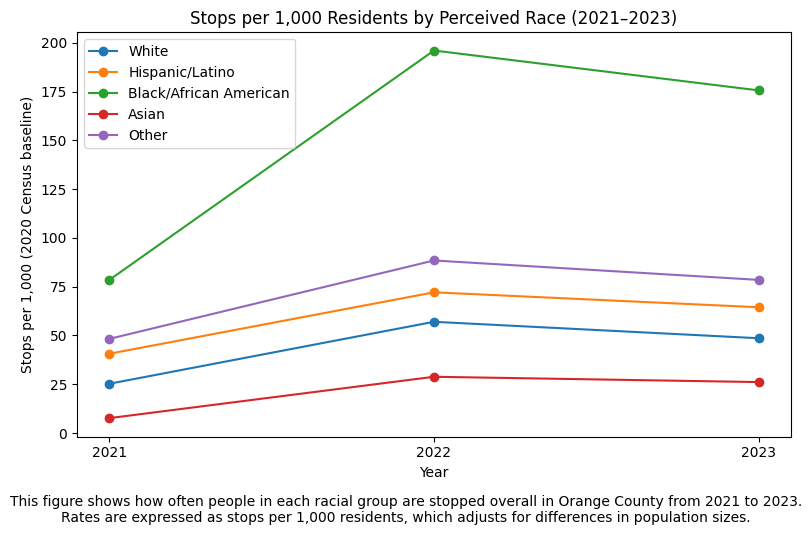

In [101]:
# Exposure over time: Stops per 1,000 (line chart)

plt.figure(figsize=(8, 5))
for race in race_order:
    d = analysis[analysis["Perceived Race"] == race].sort_values("Year")
    plt.plot(d["Year"], d["Stops per 1,000"], marker="o", label=race)

plt.title("Stops per 1,000 Residents by Perceived Race (2021–2023)")
plt.xlabel("Year")
plt.ylabel("Stops per 1,000 (2020 Census baseline)")
plt.legend()

plt.figtext(
    0.5, -0.05,
    "This figure shows how often people in each racial group are stopped overall in Orange County from 2021 to 2023. "
    "Rates are expressed as stops per 1,000 residents, which adjusts for differences in population sizes.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks([2021, 2022, 2023])
finish_plot("01_stops_per_1000_trend.png")

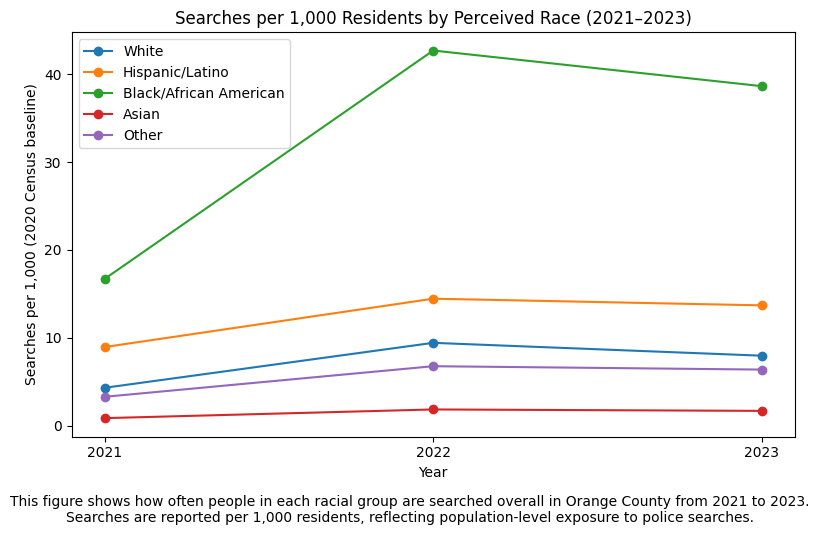

In [102]:
# Exposure over time: Searches per 1,000 (line chart)
# Shows how often people in a group are searched overall

plt.figure(figsize=(8, 5))
for race in race_order:
    d = analysis[analysis["Perceived Race"] == race].sort_values("Year")
    if len(d) > 0:
        plt.plot(d["Year"], d["Searches per 1,000"], marker="o", label=race)

plt.title("Searches per 1,000 Residents by Perceived Race (2021–2023)")
plt.xlabel("Year")
plt.ylabel("Searches per 1,000 (2020 Census baseline)")
plt.legend()

plt.figtext(
    0.5, -0.05,
    "This figure shows how often people in each racial group are searched overall in Orange County from 2021 to 2023. "
    "Searches are reported per 1,000 residents, reflecting population-level exposure to police searches.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks([2021, 2022, 2023])
finish_plot("02_searches_per_1000_trend.png")

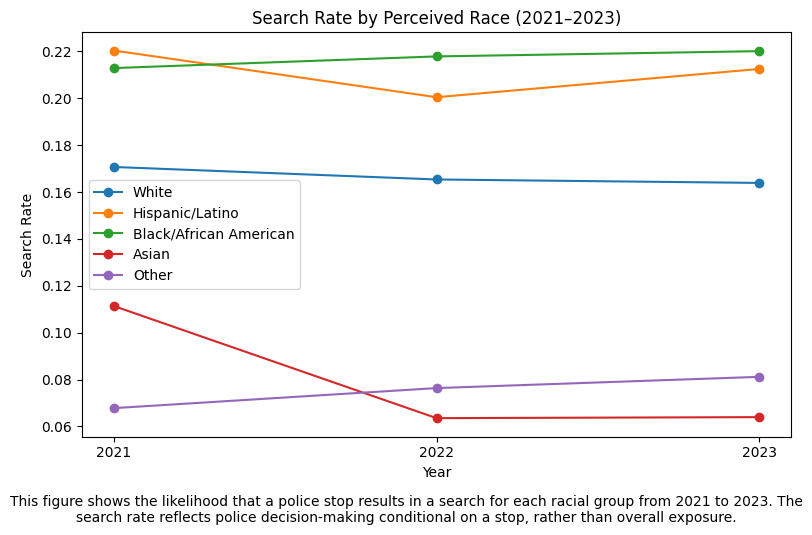

In [103]:
# Decision-making over time: Search Rate (line chart)
# Shows how often police choose to search ONCE A STOP HAS ALREADY HAPPENED

plt.figure(figsize=(8, 5))
for race in race_order:
    d = analysis[analysis["Perceived Race"] == race].sort_values("Year")
    if len(d) > 0:
        plt.plot(d["Year"], d["Search Rate"], marker="o", label=race)

plt.title("Search Rate by Perceived Race (2021–2023)")
plt.xlabel("Year")
plt.ylabel("Search Rate")
plt.legend()

plt.figtext(
    0.5, -0.05,
    "This figure shows the likelihood that a police stop results in a search for each racial group from 2021 to 2023. "
    "The search rate reflects police decision-making conditional on a stop, rather than overall exposure.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks([2021, 2022, 2023])
finish_plot("03_search_rate_trend.png")

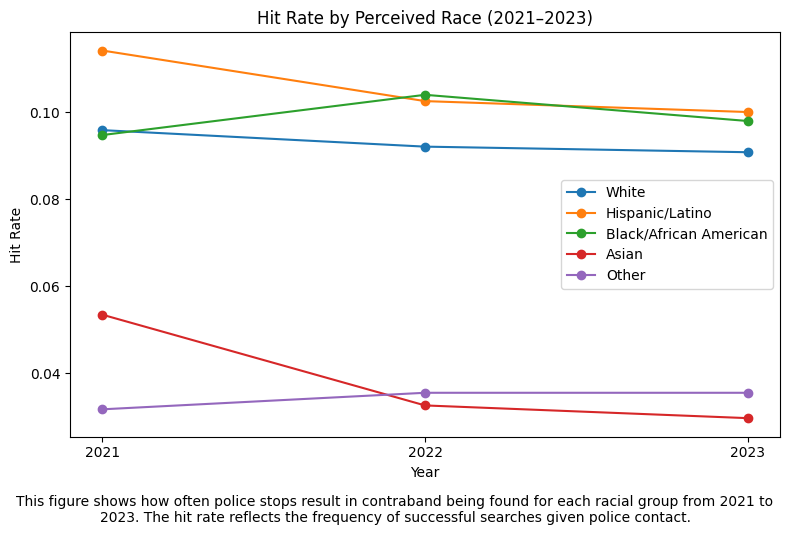

In [104]:
# Decision-making over time: Hit Rate (line chart)

plt.figure(figsize=(8, 5))
for race in race_order:
    d = analysis[analysis["Perceived Race"] == race].sort_values("Year")
    if len(d) > 0:
        plt.plot(d["Year"], d["Hit Rate"], marker="o", label=race)

plt.title("Hit Rate by Perceived Race (2021–2023)")
plt.xlabel("Year")
plt.ylabel("Hit Rate")
plt.legend()

plt.figtext(
    0.5, -0.05,
    "This figure shows how often police stops result in contraband being found for each racial group from 2021 to 2023. "
    "The hit rate reflects the frequency of successful searches given police contact.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks([2021, 2022, 2023])
finish_plot("04_hit_rate_trend.png")

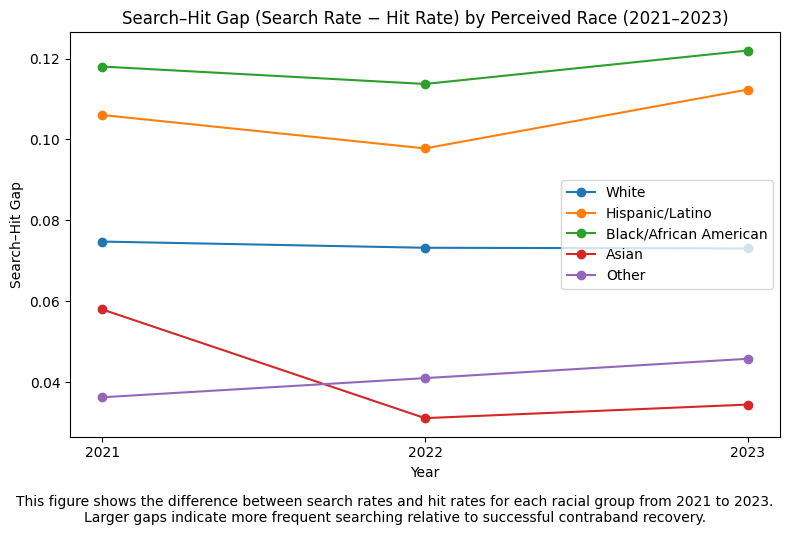

In [105]:
# Mismatch over time: Search–Hit Gap (line chart)

plt.figure(figsize=(8, 5))
for race in race_order:
    d = analysis[analysis["Perceived Race"] == race].sort_values("Year")
    if len(d) > 0:
        plt.plot(d["Year"], d["Search–Hit Gap"], marker="o", label=race)

plt.title("Search–Hit Gap (Search Rate − Hit Rate) by Perceived Race (2021–2023)")
plt.xlabel("Year")
plt.ylabel("Search–Hit Gap")
plt.legend()

plt.figtext(
    0.5, -0.05,
    "This figure shows the difference between search rates and hit rates for each racial group from 2021 to 2023. "
    "Larger gaps indicate more frequent searching relative to successful contraband recovery.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks([2021, 2022, 2023])
finish_plot("05_search_hit_gap_trend.png")

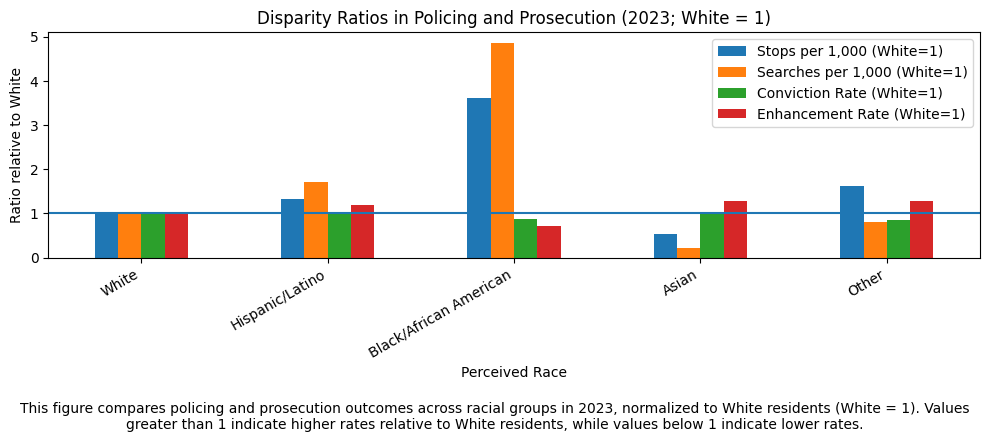

In [109]:
# 2023 headline disparities: White-normalized ratios (bar chart)

cols = [
    "Stops per 1,000 (White=1)",
    "Searches per 1,000 (White=1)",
    "Conviction Rate (White=1)",
    "Enhancement Rate (White=1)"
]
cols = [c for c in cols if c in analysis_2023.columns]  # safety

plot_df = analysis_2023.set_index("Perceived Race")[cols]

plot_df.plot(kind="bar", figsize=(10, 4))
plt.axhline(1.0)
plt.title("Disparity Ratios in Policing and Prosecution (2023; White = 1)")
plt.xlabel("Perceived Race")
plt.ylabel("Ratio relative to White")

plt.figtext(
    0.5, -0.08,
    "This figure compares policing and prosecution outcomes across racial groups in 2023, normalized to White residents "
    "(White = 1). Values greater than 1 indicate higher rates relative to White residents, while values below 1 indicate lower rates.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks(rotation=30, ha="right")
finish_plot("06_white_normalized_2023.png")

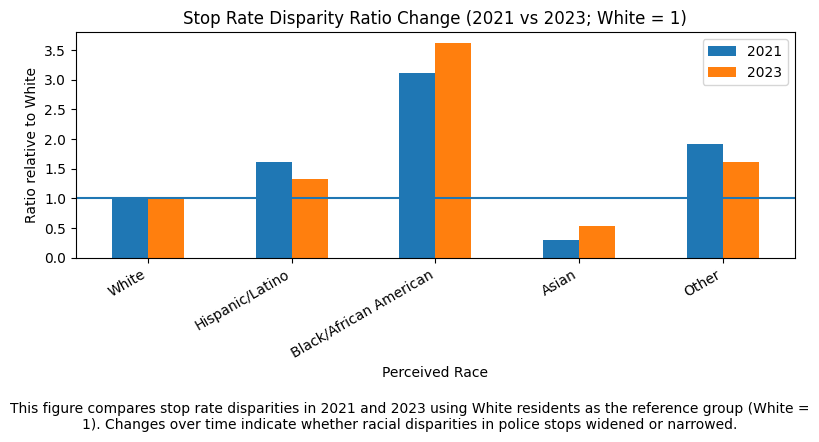

In [108]:
# 2021 vs 2023 comparison: Stops per 1,000 (White=1) (side-by-side bars)

d21 = analysis_2021.set_index("Perceived Race")["Stops per 1,000 (White=1)"]
d23 = analysis_2023.set_index("Perceived Race")["Stops per 1,000 (White=1)"]

comp = pd.DataFrame({"2021": d21, "2023": d23}).reindex(race_order)

comp.plot(kind="bar", figsize=(8, 4))
plt.axhline(1.0)
plt.title("Stop Rate Disparity Ratio Change (2021 vs 2023; White = 1)")
plt.xlabel("Perceived Race")
plt.ylabel("Ratio relative to White")

plt.figtext(
    0.5, -0.08,
    "This figure compares stop rate disparities in 2021 and 2023 using White residents as the reference group (White = 1). "
    "Changes over time indicate whether racial disparities in police stops widened or narrowed.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks(rotation=30, ha="right")
finish_plot("07_stops_ratio_2021_vs_2023.png")

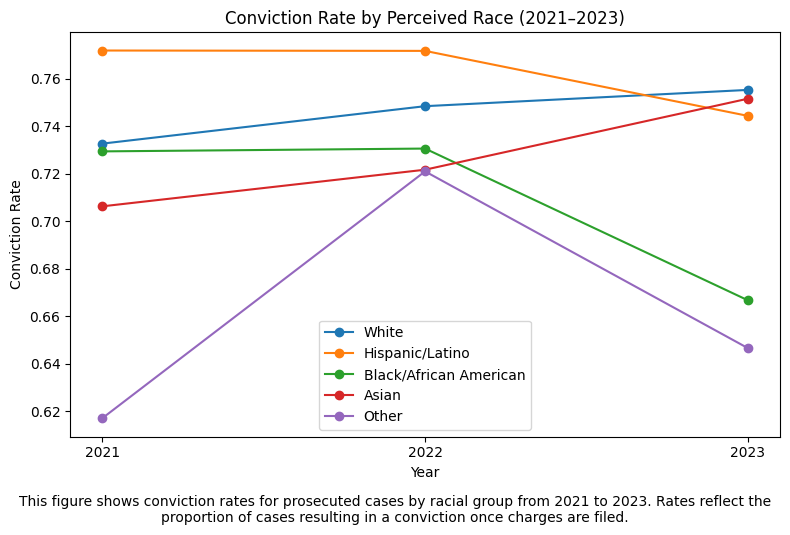

In [106]:
# Prosecution outcomes over time: Conviction Rate (line chart)

plt.figure(figsize=(8, 5))
for race in race_order:
    d = analysis[analysis["Perceived Race"] == race].sort_values("Year")
    if len(d) > 0:
        plt.plot(d["Year"], d["Conviction Rate"], marker="o", label=race)

plt.title("Conviction Rate by Perceived Race (2021–2023)")
plt.xlabel("Year")
plt.ylabel("Conviction Rate")
plt.legend()

plt.figtext(
    0.5, -0.05,
    "This figure shows conviction rates for prosecuted cases by racial group from 2021 to 2023. "
    "Rates reflect the proportion of cases resulting in a conviction once charges are filed.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks([2021, 2022, 2023])
finish_plot("08_conviction_rate_trend.png")

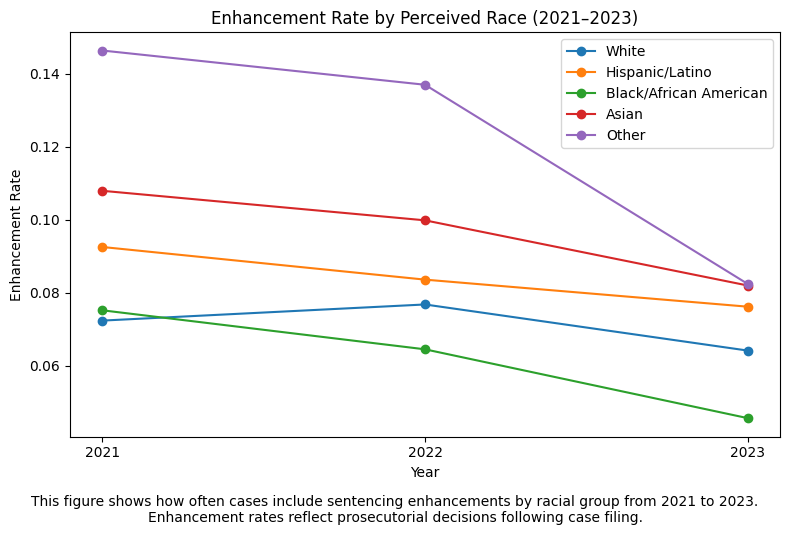

In [107]:
# Prosecution outcomes over time: Enhancement Rate (line chart)

plt.figure(figsize=(8, 5))
for race in race_order:
    d = analysis[analysis["Perceived Race"] == race].sort_values("Year")
    if len(d) > 0:
        plt.plot(d["Year"], d["Enhancement Rate"], marker="o", label=race)

plt.title("Enhancement Rate by Perceived Race (2021–2023)")
plt.xlabel("Year")
plt.ylabel("Enhancement Rate")
plt.legend()

plt.figtext(
    0.5, -0.05,
    "This figure shows how often cases include sentencing enhancements by racial group from 2021 to 2023. "
    "Enhancement rates reflect prosecutorial decisions following case filing.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.xticks([2021, 2022, 2023])
finish_plot("09_enhancement_rate_trend.png")